Import The Libraries

In [50]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics


Data Collection and Data Preprocessing


In [51]:
#Loading the data into sklearn dataset
house_price_dataset = sklearn.datasets.fetch_california_housing()

In [52]:
print(house_price_dataset)

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]]), 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]), 'frame': None, 'target_names': ['MedHouseVal'], 'feature_names': ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'], 'DESCR': '.. _california_housing_dataset:\n\nCalifornia Housing dataset\n-

In [53]:
# Loading the data into pandas Data Frame
house_price_dataframe = pd.DataFrame(house_price_dataset.data, columns = house_price_dataset.feature_names)


In [54]:
print(house_price_dataframe.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB
None


In [55]:
# add the (Target) Price column to DataFrame
house_price_dataframe['Price'] = house_price_dataset.target

In [56]:
print(house_price_dataframe.shape)

(20640, 9)


In [57]:
#Validata if missing values
print(house_price_dataframe.isnull().sum())

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64


In [58]:
# Stats Measures of dataset
print(house_price_dataframe.describe())

             MedInc      HouseAge  ...     Longitude         Price
count  20640.000000  20640.000000  ...  20640.000000  20640.000000
mean       3.870671     28.639486  ...   -119.569704      2.068558
std        1.899822     12.585558  ...      2.003532      1.153956
min        0.499900      1.000000  ...   -124.350000      0.149990
25%        2.563400     18.000000  ...   -121.800000      1.196000
50%        3.534800     29.000000  ...   -118.490000      1.797000
75%        4.743250     37.000000  ...   -118.010000      2.647250
max       15.000100     52.000000  ...   -114.310000      5.000010

[8 rows x 9 columns]


In [59]:
#Understanding the correlation between various features in dataset
correlation = house_price_dataframe.corr()


In [60]:
#Constructing heatmap to show the correlation
#plt.figure(figsize=(10,10))
#sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')

Spliting Training and Test set

In [61]:
#Spliting Data and Labels
X = house_price_dataframe.drop('Price', axis=1)
Y = house_price_dataframe['Price']
#Split sets
x_train , x_test , y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

Model Training

XGBoost Regressor

In [62]:
#Loading the Model
model = XGBRegressor()

In [63]:
model.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

Evaluation

Prediction on training data

In [64]:
#accuracy for prediction on training set
training_data_Prediction = model.predict(x_train)
print(training_data_Prediction)

[0.5523039 3.0850039 0.5835302 ... 1.9204227 1.952873  0.6768683]


In [65]:
#R_Squared_Error
score1 = metrics.r2_score(y_train, training_data_Prediction)
print('R_Squared_Mean : ', score1)

R_Squared_Mean :  0.943650140819218


In [66]:
#Mean_Absolute_Error
score2 = metrics.mean_absolute_error(y_train, training_data_Prediction)
print('Mean_Absolute_Error : ', score2)

Mean_Absolute_Error :  0.1933648700612105


Visulaization of predicted prices and actual data

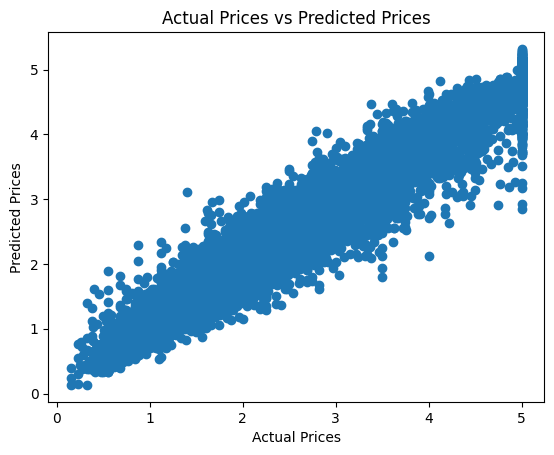

In [70]:
plt.scatter(y_train, training_data_Prediction)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")
plt.show()

Prediction on test data

In [67]:
#accuracy for prediction on test set
test_data_Prediction = model.predict(x_test)
print(test_data_Prediction)

[2.8649795  1.790346   0.92074925 ... 1.5385513  0.92647874 2.043316  ]


In [68]:
#R_Squared_Error
score3 = metrics.r2_score(y_test, test_data_Prediction)
print('R_Squared_Mean : ', score3)

R_Squared_Mean :  0.8338000331788725


In [69]:
#Mean_Absolute_Error
score4 = metrics.mean_absolute_error(y_test, test_data_Prediction)
print('Mean_Absolute_Error : ', score4)

Mean_Absolute_Error :  0.3108631800268186
